# Предсказание реакций на IT-вакансии в Telegram

**Цель:** обучить модель предсказывать распределение реакций (эмодзи) по тексту вакансии.

**Данные:** 3 Telegram-канала, ~189 сообщений с реакциями, 56 уникальных эмодзи.

**Варианты кластеризации реакций:**
- A: каждый эмодзи — отдельный таргет (~56 scores)
- B: 5 групп (cringe, laugh, hype, shock, pill)
- C: 3 группы (negative, neutral, positive)

In [1]:
%%capture
!pip install transformers torch shap wordcloud scipy scikit-learn matplotlib seaborn

In [2]:
import json
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

import shap
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Загрузка данных

In [3]:
# --- Для Google Colab: загрузить данные из Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_ROOT = Path("/content/drive/MyDrive/NLP-1")  # поменять на свой путь

DATA_ROOT = Path(".")  # локальный запуск

CHANNELS = {
    "ds_jobs": DATA_ROOT / "data science jobs data" / "result.json",
    "not_boring": DATA_ROOT / "not boring ds obs data" / "result.json",
    "ods": DATA_ROOT / "ods data" / "result.json",
}


def extract_text(text_field):
    """Извлечь чистый текст из смешанного формата Telegram export."""
    if isinstance(text_field, str):
        return text_field
    parts = []
    for item in text_field:
        if isinstance(item, str):
            parts.append(item)
        elif isinstance(item, dict):
            parts.append(item.get("text", ""))
    return "".join(parts)


def load_channel(path, channel_name):
    """Загрузить JSON и вернуть список словарей с текстом и реакциями."""
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    messages = raw.get("messages", raw) if isinstance(raw, dict) else raw

    rows = []
    for msg in messages:
        if not isinstance(msg, dict):
            continue
        reactions = msg.get("reactions", [])
        if not reactions:
            continue
        text = extract_text(msg.get("text", ""))
        if not text.strip():
            continue

        reaction_counts = {}
        for r in reactions:
            emoji = r["emoji"]
            reaction_counts[emoji] = reaction_counts.get(emoji, 0) + r["count"]

        rows.append({
            "channel": channel_name,
            "text": text.strip(),
            "date": msg.get("date", ""),
            "reactions": reaction_counts,
            "total_reactions": sum(reaction_counts.values()),
        })
    return rows


all_rows = []
for ch_name, ch_path in CHANNELS.items():
    rows = load_channel(ch_path, ch_name)
    print(f"{ch_name}: {len(rows)} сообщений с реакциями")
    all_rows.extend(rows)

df = pd.DataFrame(all_rows)
print(f"\nИтого: {len(df)} сообщений, {df['total_reactions'].sum():.0f} реакций")
df.head(2)

ds_jobs: 75 сообщений с реакциями
not_boring: 24 сообщений с реакциями
ods: 90 сообщений с реакциями

Итого: 189 сообщений, 8292 реакций


,channel,text,date,reactions,total_reactions
0,ds_jobs,CV Developer\nОпыт работы: рассмотрим без комм...,2025-11-07T13:01:00,"{'🤪': 23, '💊': 11, '🗿': 9, '😁': 4, '😡': 2, '🥰'...",50
1,ds_jobs,#вакансия #fulltime #dataanalyst #remote \n\n⚡...,2025-11-07T20:20:19,{'❤': 7},7


## 3. Обработка реакций → целевые переменные (3 варианта)\n\n| Вариант | Группы | Описание |\n|---------|--------|----------|\n| A | ~56 | Каждый эмодзи — отдельный таргет (sparse) |\n| B | 5 | cringe, laugh, hype, shock, pill |\n| C | 3 | negative, neutral, positive |

In [4]:
# --- Вариант B: 5 групп ---
GROUPS_5 = {
    "cringe":  ["🤮", "🤡", "💩", "🤬", "😡", "🖕", "🥴", "👎"],
    "laugh":   ["🤣", "😁", "🤪", "🥱", "😴", "🙈", "🙊"],
    "hype":    ["🔥", "❤", "👍", "🥰", "😍", "🤩", "👏", "🎉", "⚡", "👌", "🤝", "😇", "👀", "👨\u200d💻", "❤\u200d🔥"],
    "shock":   ["🤯", "😱", "😨", "🤔", "🤨", "😐", "😢", "😭", "💔"],
    "pill":    ["💊", "🗿", "🤓", "✍", "🌚", "💅", "🤷\u200d♀", "🤷\u200d♂"],
}

# --- Вариант C: 3 группы ---
GROUPS_3 = {
    "negative": GROUPS_5["cringe"] + GROUPS_5["pill"],
    "neutral":  GROUPS_5["laugh"] + GROUPS_5["shock"],
    "positive": GROUPS_5["hype"],
}

# Собрать все уникальные эмодзи из данных
all_emojis = sorted({e for rxn in df["reactions"] for e in rxn})
print(f"Уникальных эмодзи в данных: {len(all_emojis)}")

# Показать какие эмодзи не попали ни в одну группу (вариант B)
mapped = {e for group in GROUPS_5.values() for e in group}
unmapped = [e for e in all_emojis if e not in mapped]
print(f"Не попали в группы B: {unmapped}")
# Добавим unmapped в ближайшую по смыслу группу или создадим «other»
# Для простоты — добавляем в hype (позитивные/нейтральные) или pill (ирония)
EXTRA_MAPPING = {
    "🌭": "laugh", "🍌": "laugh", "🍓": "hype", "🎄": "hype",
    "🎅": "hype", "🐳": "hype", "🕊": "hype", "🦄": "hype", "🫡": "hype",
}
for emoji, group in EXTRA_MAPPING.items():
    GROUPS_5[group].append(emoji)
    if group in ("cringe", "pill"):
        GROUPS_3["negative"].append(emoji)
    elif group in ("laugh", "shock"):
        GROUPS_3["neutral"].append(emoji)
    else:
        GROUPS_3["positive"].append(emoji)

# Проверка — все эмодзи замаплены
mapped = {e for group in GROUPS_5.values() for e in group}
still_unmapped = [e for e in all_emojis if e not in mapped]
print(f"Осталось не замаплено: {still_unmapped}")


def compute_scores(reactions_dict, groups):
    """Вычислить долю каждой группы от общего числа реакций."""
    total = sum(reactions_dict.values())
    if total == 0:
        return {g: 0.0 for g in groups}
    scores = {}
    for group_name, emojis in groups.items():
        scores[group_name] = sum(reactions_dict.get(e, 0) for e in emojis) / total
    return scores


def compute_scores_per_emoji(reactions_dict, emoji_list):
    """Вариант A: доля каждого эмодзи."""
    total = sum(reactions_dict.values())
    if total == 0:
        return {e: 0.0 for e in emoji_list}
    return {e: reactions_dict.get(e, 0) / total for e in emoji_list}


# Вариант A — все эмодзи
scores_a = df["reactions"].apply(lambda r: compute_scores_per_emoji(r, all_emojis))
df_scores_a = pd.DataFrame(scores_a.tolist(), index=df.index)
# Убрать эмодзи, которые ни разу не встречались (если есть)
df_scores_a = df_scores_a.loc[:, df_scores_a.sum() > 0]

# Вариант B — 5 групп
scores_b = df["reactions"].apply(lambda r: compute_scores(r, GROUPS_5))
df_scores_b = pd.DataFrame(scores_b.tolist(), index=df.index)

# Вариант C — 3 группы
scores_c = df["reactions"].apply(lambda r: compute_scores(r, GROUPS_3))
df_scores_c = pd.DataFrame(scores_c.tolist(), index=df.index)

# Проверка: суммы ≈ 1
print(f"\nСуммы scores (должны быть ≈1):")
print(f"  A: min={df_scores_a.sum(axis=1).min():.4f}, max={df_scores_a.sum(axis=1).max():.4f}")
print(f"  B: min={df_scores_b.sum(axis=1).min():.4f}, max={df_scores_b.sum(axis=1).max():.4f}")
print(f"  C: min={df_scores_c.sum(axis=1).min():.4f}, max={df_scores_c.sum(axis=1).max():.4f}")

print(f"\nВариант A: {df_scores_a.shape[1]} таргетов")
print(f"Вариант B: {list(df_scores_b.columns)}")
print(f"Вариант C: {list(df_scores_c.columns)}")
df_scores_b.describe().round(3)

Уникальных эмодзи в данных: 56
Не попали в группы B: ['🌭', '🍌', '🍓', '🎄', '🎅', '🐳', '🕊', '🦄', '🫡']
Осталось не замаплено: []

Суммы scores (должны быть ≈1):
  A: min=1.0000, max=1.0000
  B: min=1.0000, max=1.8974
  C: min=1.0000, max=1.8974

Вариант A: 56 таргетов
Вариант B: ['cringe', 'laugh', 'hype', 'shock', 'pill']
Вариант C: ['negative', 'neutral', 'positive']


,cringe,laugh,hype,shock,pill
count,189.000,189.000,189.000,189.000,189.000
mean,0.235,0.219,0.389,0.047,0.123
std,0.292,0.297,0.390,0.153,0.229
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.067,0.000,0.000
50%,0.085,0.028,0.250,0.000,0.000
75%,0.500,0.488,0.714,0.000,0.133
max,1.000,1.000,1.897,1.000,1.000


## 4. EDA

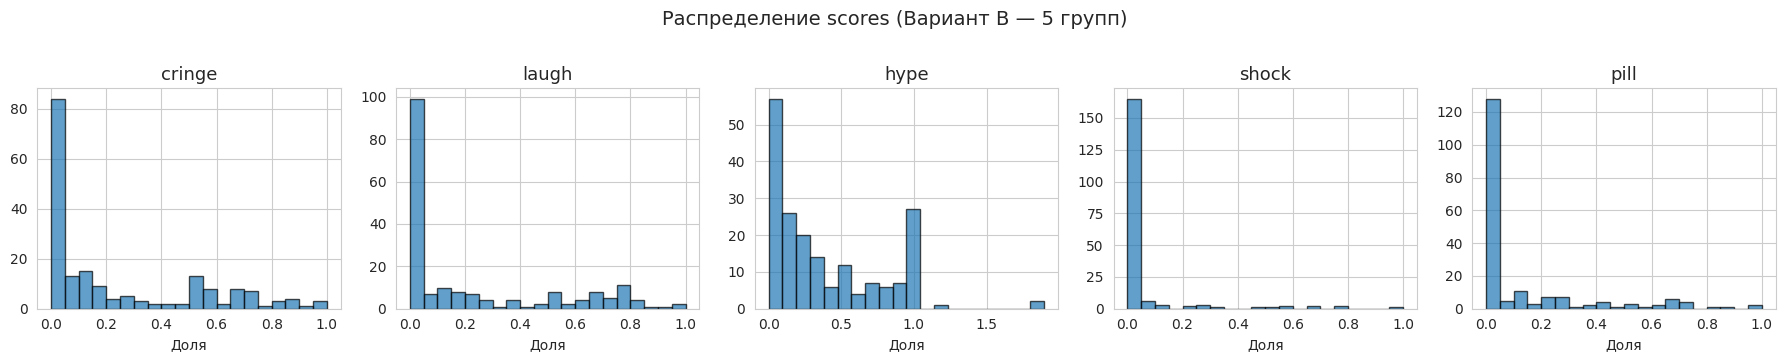

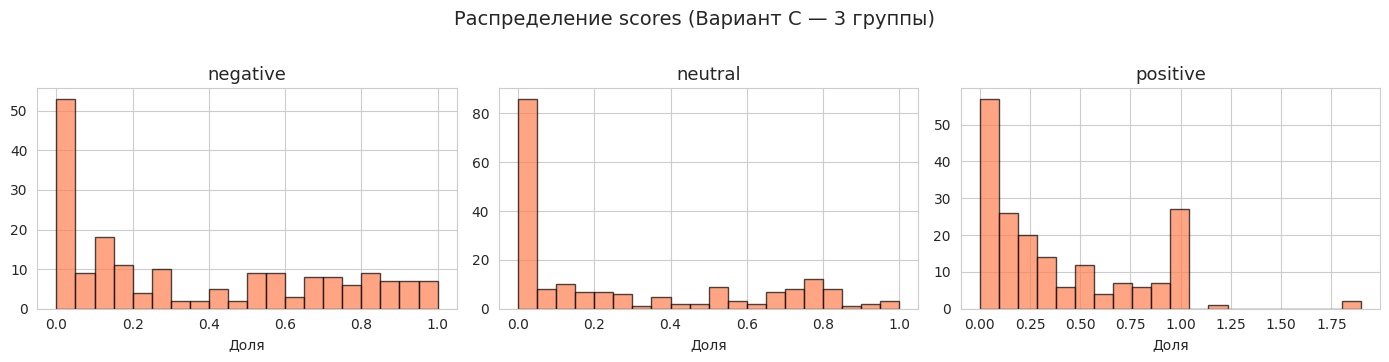

In [5]:
# Распределение scores (Вариант B — 5 групп)
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, df_scores_b.columns):
    ax.hist(df_scores_b[col], bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(col, fontsize=13)
    ax.set_xlabel("Доля")
fig.suptitle("Распределение scores (Вариант B — 5 групп)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Распределение scores (Вариант C — 3 группы)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, df_scores_c.columns):
    ax.hist(df_scores_c[col], bins=20, edgecolor="black", alpha=0.7, color="coral")
    ax.set_title(col, fontsize=13)
    ax.set_xlabel("Доля")
fig.suptitle("Распределение scores (Вариант C — 3 группы)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

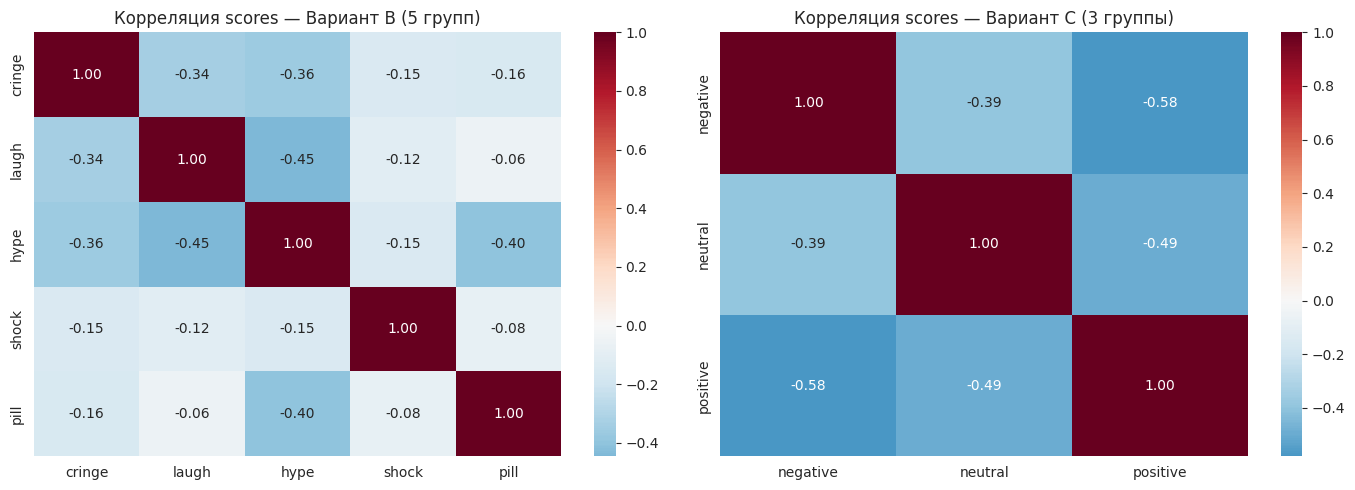

In [6]:
# Корреляции между scores (Вариант B)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_scores_b.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Корреляция scores — Вариант B (5 групп)")
sns.heatmap(df_scores_c.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("Корреляция scores — Вариант C (3 группы)")
plt.tight_layout()
plt.show()

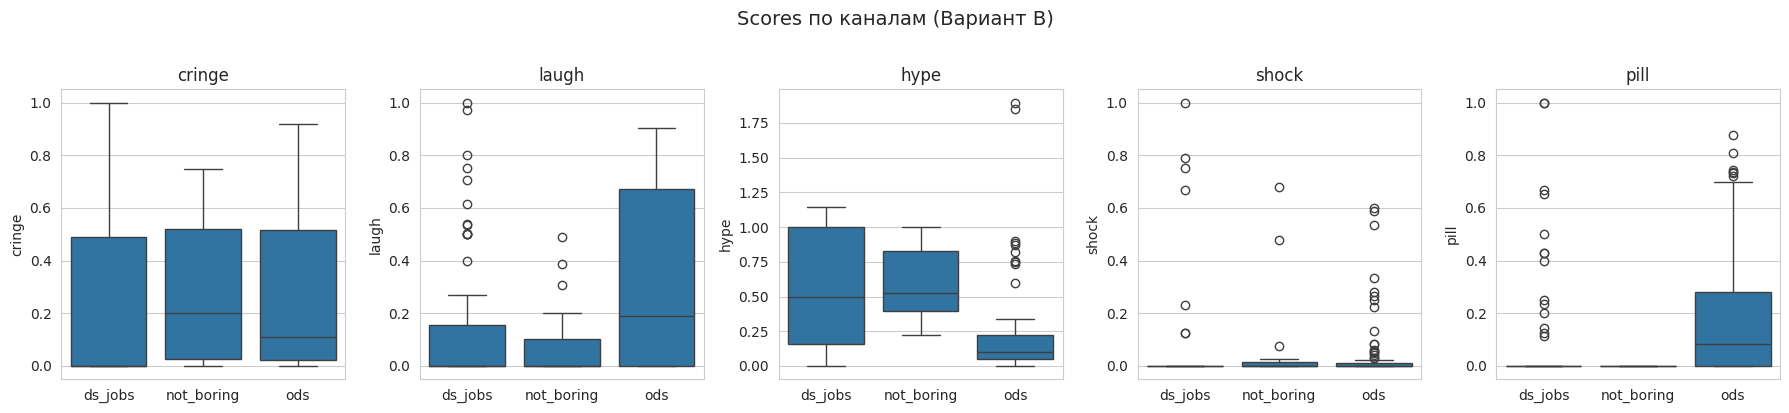

In [7]:
# Scores по каналам (boxplots)
df_plot = df[["channel"]].copy()
for col in df_scores_b.columns:
    df_plot[col] = df_scores_b[col].values

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, df_scores_b.columns):
    sns.boxplot(data=df_plot, x="channel", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Scores по каналам (Вариант B)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

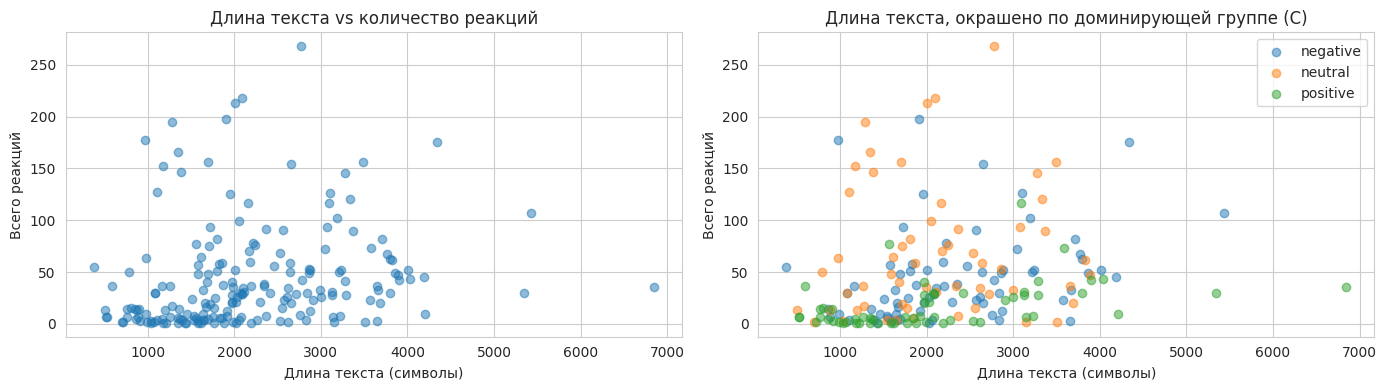

Средняя длина текста: 2187 символов, 288 слов


In [8]:
# Длина текста vs суммарные реакции
df["text_length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(df["text_length"], df["total_reactions"], alpha=0.5)
axes[0].set_xlabel("Длина текста (символы)")
axes[0].set_ylabel("Всего реакций")
axes[0].set_title("Длина текста vs количество реакций")

# Длина текста vs dominant score (вариант C)
dominant = df_scores_c.idxmax(axis=1)
for label in df_scores_c.columns:
    mask = dominant == label
    axes[1].scatter(df.loc[mask, "text_length"], df.loc[mask, "total_reactions"],
                    alpha=0.5, label=label)
axes[1].set_xlabel("Длина текста (символы)")
axes[1].set_ylabel("Всего реакций")
axes[1].set_title("Длина текста, окрашено по доминирующей группе (C)")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Средняя длина текста: {df['text_length'].mean():.0f} символов, {df['word_count'].mean():.0f} слов")

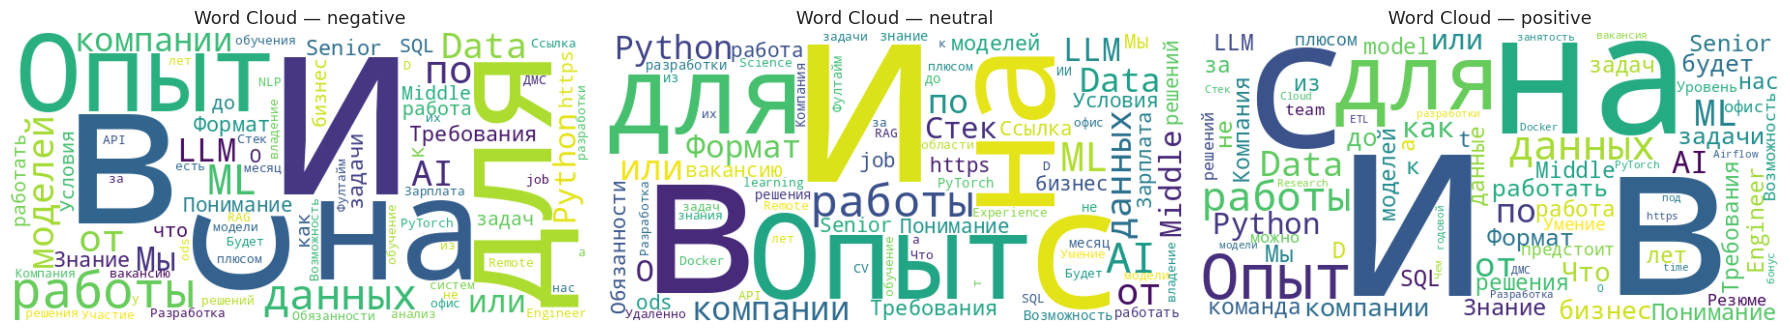

In [9]:
# Word clouds по доминирующей группе (Вариант C)
dominant_c = df_scores_c.idxmax(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, label in zip(axes, ["negative", "neutral", "positive"]):
    texts = " ".join(df.loc[dominant_c == label, "text"].values)
    if not texts.strip():
        ax.set_title(f"{label} (нет данных)")
        continue
    wc = WordCloud(width=600, height=300, background_color="white",
                   max_words=80, collocations=False).generate(texts)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Word Cloud — {label}", fontsize=13)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Препроцессинг текста

In [10]:
def clean_text(text):
    """Базовая очистка текста вакансии."""
    text = re.sub(r"http\S+|www\.\S+", "", text)        # URL
    text = re.sub(r"\S+@\S+\.\S+", "", text)             # email
    text = re.sub(r"@\w+", "", text)                      # @mentions
    text = re.sub(r"#\w+", "", text)                      # хэштеги
    text = re.sub(r"/\w+", "", text)                      # bot commands (/start и т.п.)
    text = re.sub(r"[^\w\s.,!?:;()\-–—/\n]", "", text)   # спецсимволы (оставляем пунктуацию)
    text = re.sub(r"\n{3,}", "\n\n", text)                # множественные переносы
    text = re.sub(r" {2,}", " ", text)                    # множественные пробелы
    return text.strip()

df["text_clean"] = df["text"].apply(clean_text)
print(f"Пример очищенного текста:\n{df['text_clean'].iloc[0][:500]}")

Пример очищенного текста:
CV Developer
Опыт работы: рассмотрим без коммерческого опыта
Вилка 30000 рублей
График: 5
Формат работы: удалённо
Чем предстоит заниматься:
- сбор и первичная очистка датасетов 
- разметка
- запуск пайплайнов и обучение базовых CV-моделей (классификация)
- анализ результатов и ведение коротких отчетов

Кого ищем?
Студентов последних курсов или начинающих разработчиков со средним уровнем Python, опытом работы с Linux и интересом к ML 

Будет плюсом: OpenCV, опыт работы с CVAT, базовое понимание Y


## 6. Train/Test Split

In [11]:
# Стратификация по доминирующей группе (Вариант C)
dominant_label = df_scores_c.idxmax(axis=1)

train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=SEED, stratify=dominant_label
)

print(f"Train: {len(train_idx)}, Test: {len(test_idx)}")
print(f"Распределение доминирующих групп в train:")
print(dominant_label.loc[train_idx].value_counts())
print(f"\nРаспределение доминирующих групп в test:")
print(dominant_label.loc[test_idx].value_counts())

Train: 151, Test: 38
Распределение доминирующих групп в train:
negative    59
positive    46
neutral     46
Name: count, dtype: int64

Распределение доминирующих групп в test:
negative    15
positive    12
neutral     11
Name: count, dtype: int64


## 7. Baseline: TF-IDF + Ridge / GradientBoosting

In [12]:
def softmax_rows(arr):
    """Ренормализация предсказаний: clamp к [0,1] и нормировка в сумме к 1."""
    arr = np.clip(arr, 0, None)
    row_sums = arr.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    return arr / row_sums


def evaluate_predictions(y_true, y_pred, label=""):
    """Вычислить JSD, MSE, Spearman для каждого score."""
    n_scores = y_true.shape[1]

    # Jensen-Shannon Divergence (по строкам)
    jsd_values = []
    for i in range(len(y_true)):
        p = y_true[i] + 1e-10
        q = y_pred[i] + 1e-10
        p = p / p.sum()
        q = q / q.sum()
        jsd_values.append(jensenshannon(p, q))
    mean_jsd = np.mean(jsd_values)

    # MSE per score
    mse_per_score = np.mean((y_true - y_pred) ** 2, axis=0)

    # Spearman per score
    spearman_per_score = []
    for j in range(n_scores):
        if np.std(y_true[:, j]) < 1e-10 or np.std(y_pred[:, j]) < 1e-10:
            spearman_per_score.append(0.0)
        else:
            rho, _ = spearmanr(y_true[:, j], y_pred[:, j])
            spearman_per_score.append(rho)

    return {
        "label": label,
        "mean_jsd": mean_jsd,
        "mean_mse": np.mean(mse_per_score),
        "mse_per_score": mse_per_score,
        "mean_spearman": np.mean(spearman_per_score),
        "spearman_per_score": spearman_per_score,
    }


def build_features(df_data, train_idx, test_idx, tfidf=None, ohe=None, fit=True):
    """Построить TF-IDF + доп. фичи."""
    if fit:
        tfidf = TfidfVectorizer(
            max_features=3000, ngram_range=(1, 2),
            sublinear_tf=True, min_df=2
        )
        X_tfidf_train = tfidf.fit_transform(df_data.loc[train_idx, "text_clean"])
        ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        ohe.fit(df_data.loc[train_idx, ["channel"]])
    else:
        X_tfidf_train = tfidf.transform(df_data.loc[train_idx, "text_clean"])

    X_tfidf_test = tfidf.transform(df_data.loc[test_idx, "text_clean"])

    # Доп. фичи
    extra_train = np.column_stack([
        ohe.transform(df_data.loc[train_idx, ["channel"]]),
        df_data.loc[train_idx, "text_length"].values.reshape(-1, 1),
        df_data.loc[train_idx, "word_count"].values.reshape(-1, 1),
    ])
    extra_test = np.column_stack([
        ohe.transform(df_data.loc[test_idx, ["channel"]]),
        df_data.loc[test_idx, "text_length"].values.reshape(-1, 1),
        df_data.loc[test_idx, "word_count"].values.reshape(-1, 1),
    ])

    from scipy.sparse import hstack
    X_train = hstack([X_tfidf_train, extra_train]).tocsr()
    X_test = hstack([X_tfidf_test, extra_test]).tocsr()

    return X_train, X_test, tfidf, ohe


X_train, X_test, tfidf_vec, ohe_enc = build_features(df, train_idx, test_idx)
print(f"Размер фичей: train {X_train.shape}, test {X_test.shape}")

Размер фичей: train (151, 3005), test (38, 3005)


In [13]:
# Обучение TF-IDF моделей по всем 3 вариантам кластеризации
all_results = []
all_variants = {
    "A": df_scores_a,
    "B": df_scores_b,
    "C": df_scores_c,
}

for variant_name, df_scores in all_variants.items():
    y_train = df_scores.loc[train_idx].values
    y_test = df_scores.loc[test_idx].values
    score_names = list(df_scores.columns)

    # --- Ridge ---
    ridge = MultiOutputRegressor(Ridge(alpha=1.0))
    ridge.fit(X_train, y_train)
    y_pred_ridge = softmax_rows(ridge.predict(X_test))
    res_ridge = evaluate_predictions(y_test, y_pred_ridge, f"TF-IDF+Ridge ({variant_name})")
    res_ridge["variant"] = variant_name
    res_ridge["model"] = "Ridge"
    res_ridge["score_names"] = score_names
    all_results.append(res_ridge)

    # --- GradientBoosting (только для B и C, A слишком много таргетов) ---
    if variant_name in ("B", "C"):
        gb = MultiOutputRegressor(
            GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=SEED)
        )
        gb.fit(X_train, y_train)
        y_pred_gb = softmax_rows(gb.predict(X_test))
        res_gb = evaluate_predictions(y_test, y_pred_gb, f"TF-IDF+GB ({variant_name})")
        res_gb["variant"] = variant_name
        res_gb["model"] = "GradientBoosting"
        res_gb["score_names"] = score_names
        all_results.append(res_gb)

    print(f"Вариант {variant_name}: Ridge JSD={res_ridge['mean_jsd']:.4f}, "
          f"MSE={res_ridge['mean_mse']:.4f}, Spearman={res_ridge['mean_spearman']:.3f}")
    if variant_name in ("B", "C"):
        print(f"Вариант {variant_name}: GB    JSD={res_gb['mean_jsd']:.4f}, "
              f"MSE={res_gb['mean_mse']:.4f}, Spearman={res_gb['mean_spearman']:.3f}")

Вариант A: Ridge JSD=0.5785, MSE=0.0068, Spearman=0.050
Вариант B: Ridge JSD=0.4230, MSE=0.0731, Spearman=0.293
Вариант B: GB    JSD=0.4269, MSE=0.0826, Spearman=0.306
Вариант C: Ridge JSD=0.3583, MSE=0.1187, Spearman=0.309
Вариант C: GB    JSD=0.3791, MSE=0.1386, Spearman=0.198


## 8. Transformer: ruBERT-tiny2\n\nМодель `cointegrated/rubert-tiny2` (29M params) — оптимальна для малого датасета.\n\nАрхитектура: mean pooling → linear head → softmax. Loss: KL-divergence.

In [14]:
MODEL_NAME = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
print(f"Параметров в модели: {sum(p.numel() for p in bert_model.parameters()) / 1e6:.1f}M")

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметров в модели: 29.2M


In [15]:
class VacancyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512, augment=False):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.augment = augment

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        # Data augmentation: случайное удаление абзаца (p=0.2)
        if self.augment and np.random.random() < 0.2:
            paragraphs = text.split("\n\n")
            if len(paragraphs) > 2:
                drop_idx = np.random.randint(0, len(paragraphs))
                paragraphs = [p for i, p in enumerate(paragraphs) if i != drop_idx]
                text = "\n\n".join(paragraphs)

        encoding = self.tokenizer(
            text, max_length=self.max_len, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }


class ReactionPredictor(nn.Module):
    def __init__(self, bert, n_outputs, freeze_layers=True):
        super().__init__()
        self.bert = bert
        hidden_size = bert.config.hidden_size

        # Заморозить все кроме последних 2 encoder слоёв
        if freeze_layers:
            for param in self.bert.embeddings.parameters():
                param.requires_grad = False
            n_layers = len(self.bert.encoder.layer)
            for i, layer in enumerate(self.bert.encoder.layer):
                if i < n_layers - 2:
                    for param in layer.parameters():
                        param.requires_grad = False

        self.head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(hidden_size, n_outputs),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Mean pooling
        last_hidden = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1)
        logits = self.head(pooled)
        probs = torch.softmax(logits, dim=-1)
        return probs


def train_transformer(variant_name, df_scores, train_idx, test_idx, epochs=20, lr_backbone=2e-5, lr_head=1e-4, batch_size=8):
    """Обучить ruBERT-tiny2 на одном варианте кластеризации."""
    score_names = list(df_scores.columns)
    n_outputs = len(score_names)

    y_train = df_scores.loc[train_idx].values
    y_test = df_scores.loc[test_idx].values
    texts_train = df.loc[train_idx, "text_clean"].values.tolist()
    texts_test = df.loc[test_idx, "text_clean"].values.tolist()

    train_ds = VacancyDataset(texts_train, y_train, tokenizer, augment=True)
    test_ds = VacancyDataset(texts_test, y_test, tokenizer, augment=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    # Модель
    bert = AutoModel.from_pretrained(MODEL_NAME)
    model = ReactionPredictor(bert, n_outputs).to(device)

    # Разные lr для backbone и head
    backbone_params = [p for n, p in model.named_parameters() if "head" not in n and p.requires_grad]
    head_params = [p for n, p in model.named_parameters() if "head" in n]
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": lr_backbone},
        {"params": head_params, "lr": lr_head},
    ], weight_decay=0.01)

    kl_loss = nn.KLDivLoss(reduction="batchmean")

    best_val_loss = float("inf")
    patience = 4
    patience_counter = 0
    best_state = None
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        # Train
        model.train()
        train_losses = []
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            probs = model(input_ids, attention_mask)
            log_probs = torch.log(probs + 1e-10)
            loss = kl_loss(log_probs, labels + 1e-10)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # Eval
        model.eval()
        val_losses = []
        all_preds = []
        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                probs = model(input_ids, attention_mask)
                log_probs = torch.log(probs + 1e-10)
                loss = kl_loss(log_probs, labels + 1e-10)
                val_losses.append(loss.item())
                all_preds.append(probs.cpu().numpy())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or patience_counter >= patience:
            print(f"  Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    # Лучшая модель — предсказания
    model.load_state_dict(best_state)
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            probs = model(input_ids, attention_mask)
            all_preds.append(probs.cpu().numpy())

    y_pred = np.vstack(all_preds)
    result = evaluate_predictions(y_test, y_pred, f"ruBERT-tiny2 ({variant_name})")
    result["variant"] = variant_name
    result["model"] = "ruBERT-tiny2"
    result["score_names"] = score_names

    return result, model, history

In [16]:
# Обучение transformer по вариантам B и C (A пропускаем — 56 таргетов на 189 сэмплах нестабильно)
transformer_models = {}

for variant_name, df_scores in [("B", df_scores_b), ("C", df_scores_c)]:
    print(f"\n{'='*50}")
    print(f"Обучение ruBERT-tiny2, Вариант {variant_name} ({df_scores.shape[1]} scores)")
    print(f"{'='*50}")
    result, model, history = train_transformer(variant_name, df_scores, train_idx, test_idx)
    all_results.append(result)
    transformer_models[variant_name] = (model, history)
    print(f"  JSD={result['mean_jsd']:.4f}, MSE={result['mean_mse']:.4f}, Spearman={result['mean_spearman']:.3f}")


Обучение ruBERT-tiny2, Вариант B (5 scores)


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 5/20: train_loss=0.8628, val_loss=0.7722
  Epoch 10/20: train_loss=0.8289, val_loss=0.7679
  Epoch 15/20: train_loss=0.7865, val_loss=0.7664
  Early stopping at epoch 15
  JSD=0.4372, MSE=0.0750, Spearman=0.225

Обучение ruBERT-tiny2, Вариант C (3 scores)


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 5/20: train_loss=0.5784, val_loss=0.5841
  Epoch 6/20: train_loss=0.5684, val_loss=0.5800
  Early stopping at epoch 6
  JSD=0.3788, MSE=0.1208, Spearman=0.002


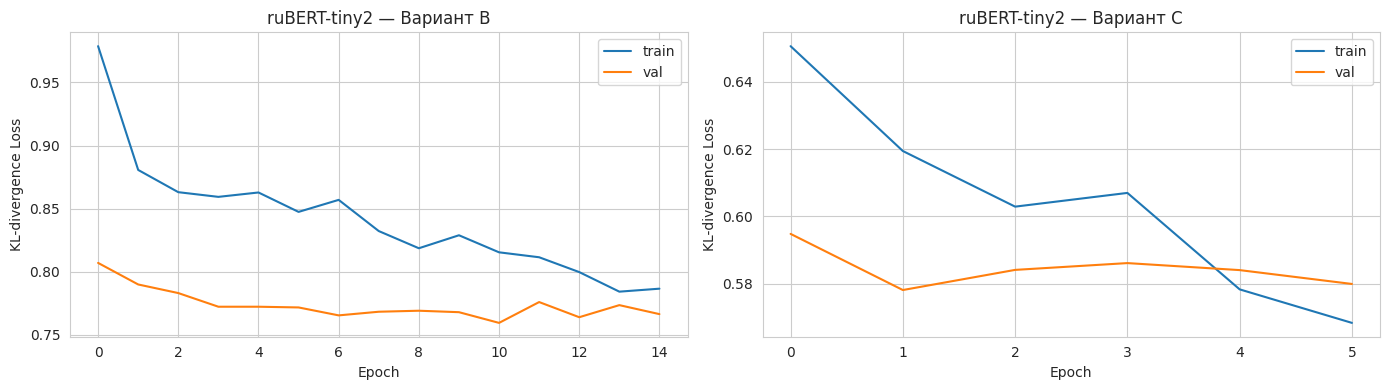

In [17]:
# Кривые обучения transformer
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (variant_name, (model, history)) in zip(axes, transformer_models.items()):
    ax.plot(history["train_loss"], label="train")
    ax.plot(history["val_loss"], label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL-divergence Loss")
    ax.set_title(f"ruBERT-tiny2 — Вариант {variant_name}")
    ax.legend()
plt.tight_layout()
plt.show()

## 9. Explainability (SHAP)\n\nДля TF-IDF+Ridge — `shap.LinearExplainer`: какие слова двигают каждый score.\nДля transformer — визуализация attention weights.

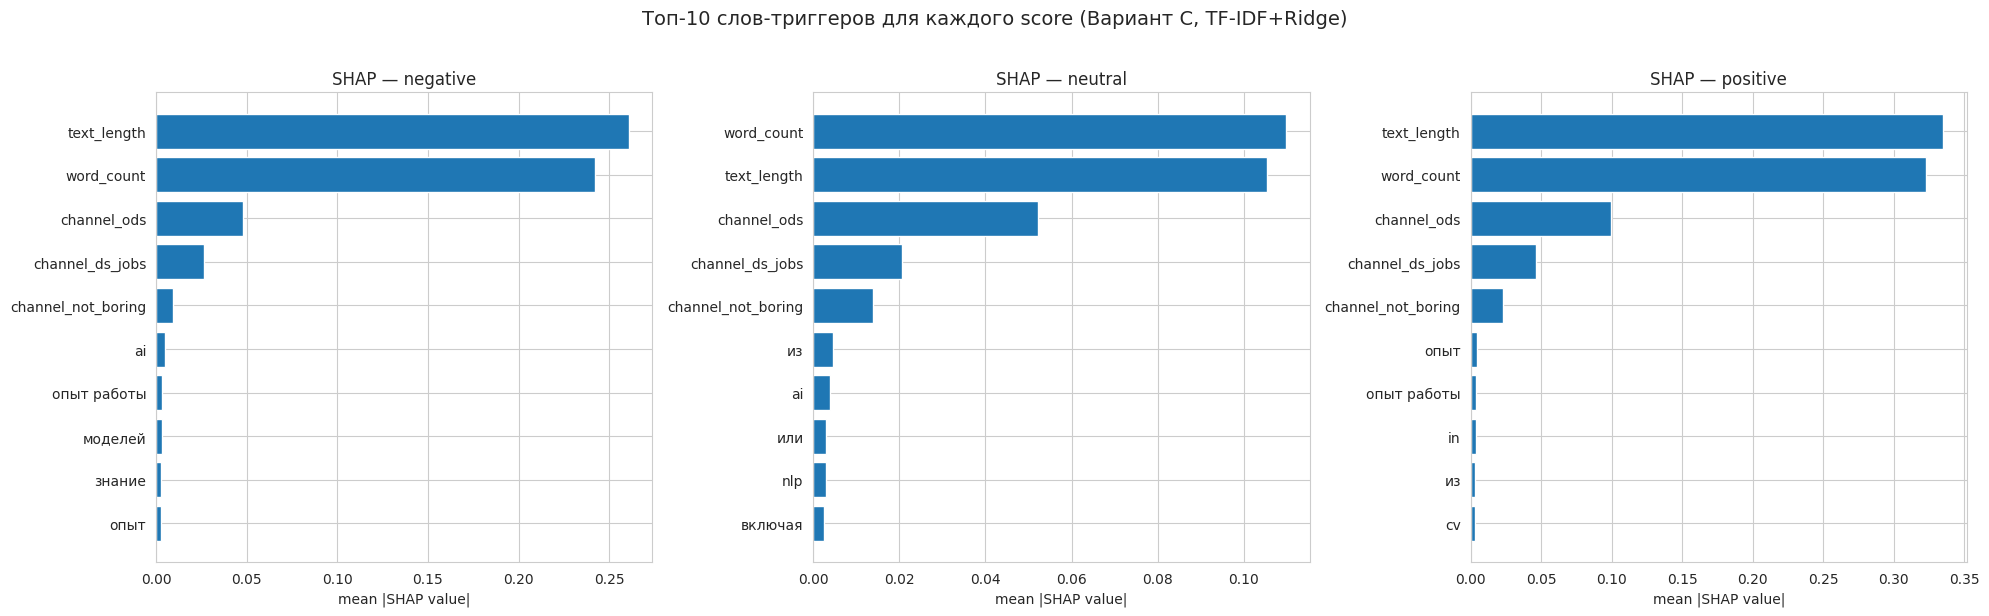

In [18]:
# SHAP для TF-IDF + Ridge (Вариант C — 3 группы, самый интерпретируемый)
y_train_c = df_scores_c.loc[train_idx].values
ridge_c = MultiOutputRegressor(Ridge(alpha=1.0))
ridge_c.fit(X_train, y_train_c)

feature_names = tfidf_vec.get_feature_names_out().tolist() + \
    list(ohe_enc.get_feature_names_out()) + ["text_length", "word_count"]

# SHAP для каждого отдельного Ridge-регрессора
score_names_c = list(df_scores_c.columns)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (score_name, estimator) in enumerate(zip(score_names_c, ridge_c.estimators_)):
    explainer = shap.LinearExplainer(estimator, X_train, feature_names=feature_names)
    shap_values = explainer.shap_values(X_test)

    # Топ-10 фичей по среднему |SHAP|
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[-10:][::-1]
    top_features = [feature_names[j] for j in top_idx]
    top_values = mean_abs_shap[top_idx]

    axes[i].barh(range(len(top_features)), top_values[::-1])
    axes[i].set_yticks(range(len(top_features)))
    axes[i].set_yticklabels(top_features[::-1])
    axes[i].set_title(f"SHAP — {score_name}")
    axes[i].set_xlabel("mean |SHAP value|")

plt.suptitle("Топ-10 слов-триггеров для каждого score (Вариант C, TF-IDF+Ridge)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


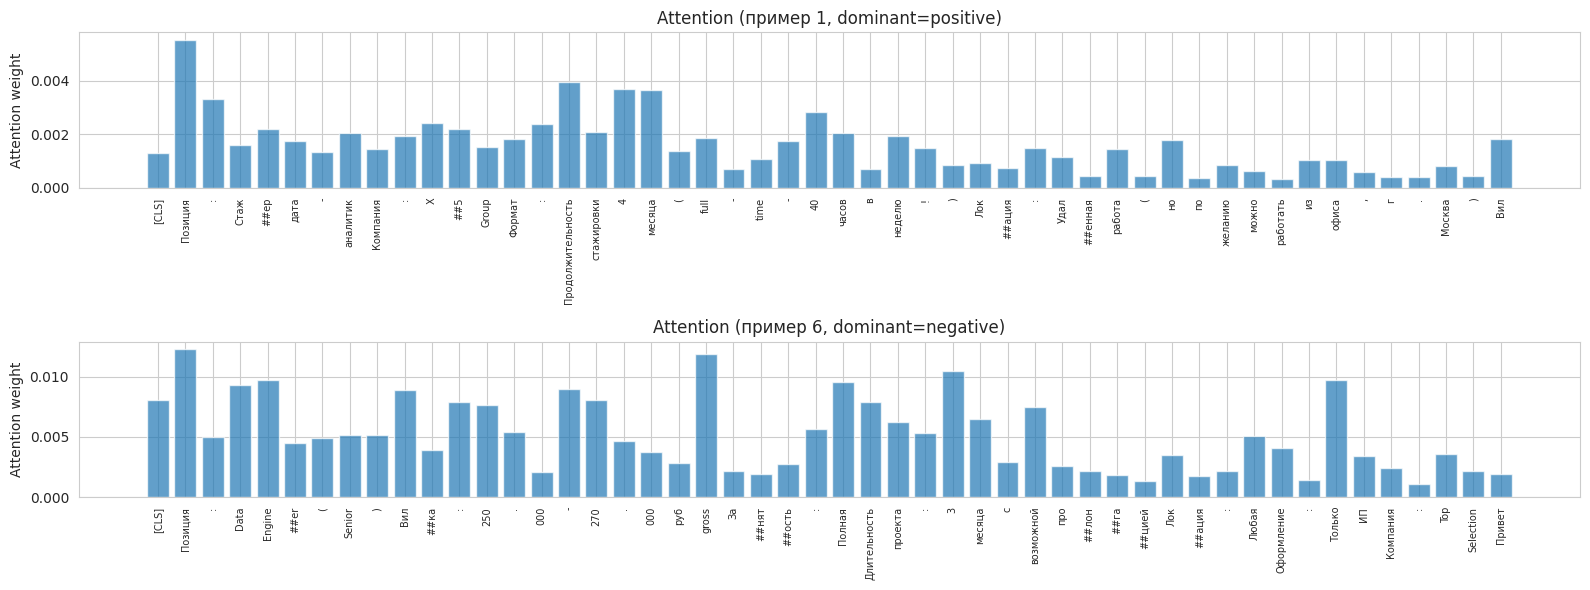

In [20]:
# Attention visualization для ruBERT-tiny2 (Вариант C)
def get_attention_weights(model, text, tokenizer, device):
    """Получить средние attention weights для текста."""
    encoding = tokenizer(text, max_length=512, padding="max_length",
                         truncation=True, return_tensors="pt")
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # Загрузить отдельную копию bert с eager attention для извлечения весов
    if not hasattr(get_attention_weights, "_eager_bert"):
        get_attention_weights._eager_bert = AutoModel.from_pretrained(
            MODEL_NAME, attn_implementation="eager"
        ).to(device).eval()
        # Скопировать веса из обученной модели
        get_attention_weights._eager_bert.load_state_dict(model.bert.state_dict())
    eager_bert = get_attention_weights._eager_bert

    with torch.no_grad():
        outputs = eager_bert(input_ids=input_ids, attention_mask=attention_mask,
                             output_attentions=True)

    # Средний attention по всем головам последнего слоя
    last_layer_attn = outputs.attentions[-1]  # (1, n_heads, seq_len, seq_len)
    avg_attn = last_layer_attn.mean(dim=1).squeeze(0)  # (seq_len, seq_len)

    # Attention от [CLS] к каждому токену
    cls_attn = avg_attn[0].cpu().numpy()

    # Убрать padding
    seq_len = attention_mask.sum().item()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0][:int(seq_len)])
    attn_weights = cls_attn[:int(seq_len)]

    return tokens, attn_weights

# Показать attention для 2 примеров из теста
if "C" in transformer_models:
    model_c = transformer_models["C"][0]
    # Сбросить кэш eager bert при новом запуске
    if hasattr(get_attention_weights, "_eager_bert"):
        del get_attention_weights._eager_bert

    fig, axes = plt.subplots(2, 1, figsize=(16, 6))
    for ax_idx, sample_idx in enumerate([0, min(5, len(test_idx)-1)]):
        real_idx = test_idx[sample_idx]
        text = df.loc[real_idx, "text_clean"]
        tokens, attn = get_attention_weights(model_c, text, tokenizer, device)

        # Показать первые 50 токенов
        n_show = min(50, len(tokens))
        ax = axes[ax_idx]
        ax.bar(range(n_show), attn[:n_show], alpha=0.7)
        ax.set_xticks(range(n_show))
        ax.set_xticklabels(tokens[:n_show], rotation=90, fontsize=7)
        ax.set_ylabel("Attention weight")
        ax.set_title(f"Attention (пример {sample_idx+1}, "
                     f"dominant={df_scores_c.loc[real_idx].idxmax()})")
    plt.tight_layout()
    plt.show()

## 10. Оценка и сравнение\n\n**Метрики:**\n- Jensen-Shannon Divergence (основная — чем меньше, тем лучше)\n- MSE per score\n- Spearman rank correlation per score

In [21]:
# Сводная таблица результатов
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Вариант": r["variant"],
        "Модель": r["model"],
        "JSD (mean)": round(r["mean_jsd"], 4),
        "MSE (mean)": round(r["mean_mse"], 4),
        "Spearman (mean)": round(r["mean_spearman"], 3),
    })

df_summary = pd.DataFrame(summary_rows).sort_values(["Вариант", "JSD (mean)"])
print("Сводная таблица результатов:")
df_summary

Сводная таблица результатов:


,Вариант,Модель,JSD (mean),MSE (mean),Spearman (mean)
0,A,Ridge,0.5785,0.0068,0.050
1,B,Ridge,0.4230,0.0731,0.293
2,B,GradientBoosting,0.4269,0.0826,0.306
5,B,ruBERT-tiny2,0.4372,0.0750,0.225
3,C,Ridge,0.3583,0.1187,0.309
6,C,ruBERT-tiny2,0.3788,0.1208,0.002
4,C,GradientBoosting,0.3791,0.1386,0.198


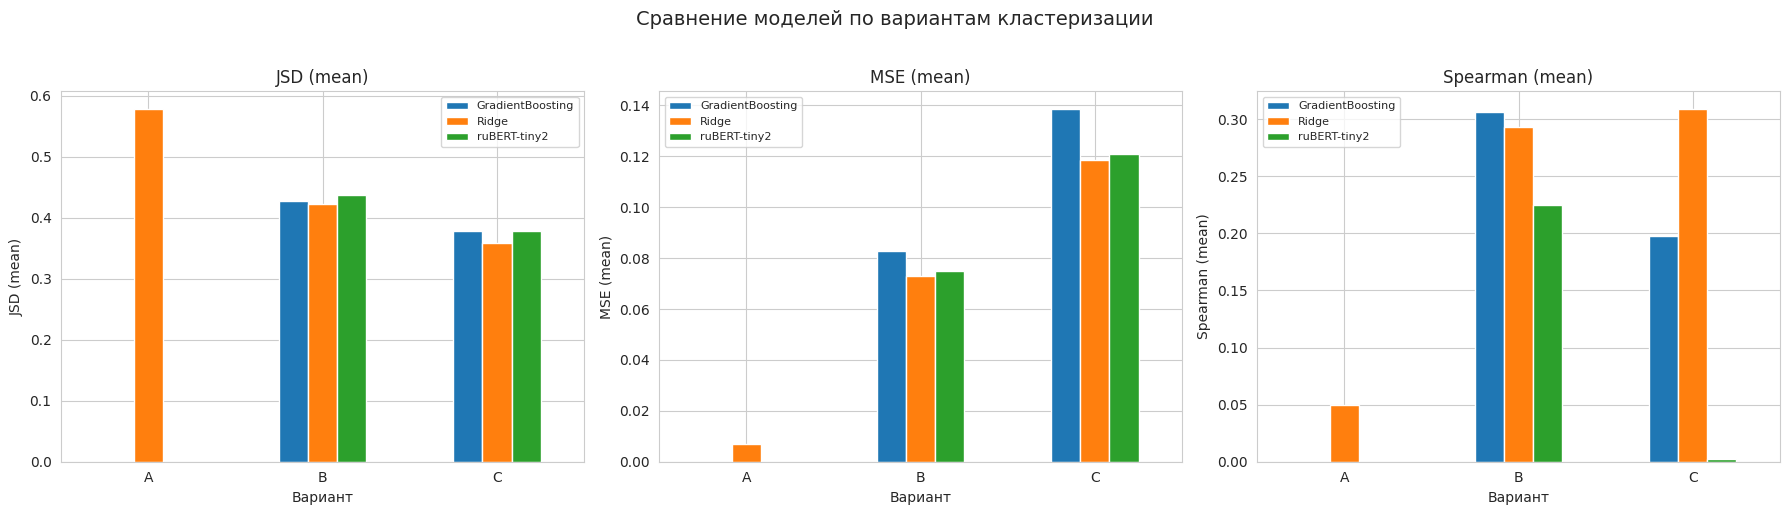

In [22]:
# Визуализация сравнения моделей
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["JSD (mean)", "MSE (mean)", "Spearman (mean)"]
for ax, metric in zip(axes, metrics):
    pivot = df_summary.pivot(index="Вариант", columns="Модель", values=metric)
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)

plt.suptitle("Сравнение моделей по вариантам кластеризации", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Детальная таблица: Spearman per score для вариантов B и C
print("Spearman per score (Вариант B — 5 групп):")
for r in all_results:
    if r["variant"] == "B":
        scores = {name: round(val, 3) for name, val in zip(r["score_names"], r["spearman_per_score"])}
        print(f"  {r['model']}: {scores}")

print("\nSpearman per score (Вариант C — 3 группы):")
for r in all_results:
    if r["variant"] == "C":
        scores = {name: round(val, 3) for name, val in zip(r["score_names"], r["spearman_per_score"])}
        print(f"  {r['model']}: {scores}")

Spearman per score (Вариант B — 5 групп):
  Ridge: {'cringe': np.float64(0.177), 'laugh': np.float64(0.418), 'hype': np.float64(0.549), 'shock': np.float64(0.004), 'pill': np.float64(0.319)}
  GradientBoosting: {'cringe': np.float64(0.069), 'laugh': np.float64(0.416), 'hype': np.float64(0.509), 'shock': np.float64(0.242), 'pill': np.float64(0.296)}
  ruBERT-tiny2: {'cringe': np.float64(0.139), 'laugh': np.float64(0.1), 'hype': np.float64(0.338), 'shock': np.float64(0.032), 'pill': np.float64(0.515)}

Spearman per score (Вариант C — 3 группы):
  Ridge: {'negative': np.float64(0.041), 'neutral': np.float64(0.337), 'positive': np.float64(0.549)}
  GradientBoosting: {'negative': np.float64(-0.168), 'neutral': np.float64(0.262), 'positive': np.float64(0.5)}
  ruBERT-tiny2: {'negative': np.float64(0.113), 'neutral': np.float64(-0.003), 'positive': np.float64(-0.103)}


In [24]:
# Bootstrap confidence intervals для лучшей модели (Вариант C)
def bootstrap_jsd(y_true, y_pred, n_bootstrap=1000, seed=42):
    """Bootstrap CI для JSD."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    jsd_scores = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        jsd_vals = []
        for i in idx:
            p = y_true[i] + 1e-10
            q = y_pred[i] + 1e-10
            p = p / p.sum()
            q = q / q.sum()
            jsd_vals.append(jensenshannon(p, q))
        jsd_scores.append(np.mean(jsd_vals))
    return np.percentile(jsd_scores, [2.5, 50, 97.5])


# Пересчитать предсказания Ridge для варианта C
y_test_c = df_scores_c.loc[test_idx].values
y_pred_ridge_c = softmax_rows(ridge_c.predict(X_test))

ci_ridge = bootstrap_jsd(y_test_c, y_pred_ridge_c)
print(f"Ridge (C): JSD median={ci_ridge[1]:.4f}, 95% CI=[{ci_ridge[0]:.4f}, {ci_ridge[2]:.4f}]")

# Bootstrap для transformer (C)
if "C" in transformer_models:
    model_c = transformer_models["C"][0]
    model_c.eval()
    test_ds = VacancyDataset(
        df.loc[test_idx, "text_clean"].values.tolist(),
        y_test_c, tokenizer, augment=False
    )
    test_loader = DataLoader(test_ds, batch_size=8)
    all_preds = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            probs = model_c(input_ids, attention_mask)
            all_preds.append(probs.cpu().numpy())
    y_pred_bert_c = np.vstack(all_preds)

    ci_bert = bootstrap_jsd(y_test_c, y_pred_bert_c)
    print(f"ruBERT (C): JSD median={ci_bert[1]:.4f}, 95% CI=[{ci_bert[0]:.4f}, {ci_bert[2]:.4f}]")

Ridge (C): JSD median=0.3569, 95% CI=[0.3137, 0.4055]
ruBERT (C): JSD median=0.3787, 95% CI=[0.3504, 0.4059]
